In [1]:
from insilicoICH.ground_truth_definition.phantoms import load_phantom
age = 6.5
phantom = load_phantom(age)

import numpy as np
volumes = np.array([5])
intensities = np.array([80])
lesion_type = 'IPH'

lesions = []
for intensity, volume in zip(intensities, volumes):
    lesion_definition = dict(
        volume=volume,
        intensity=intensity,
        lesion_type=lesion_type,
        seed=336  # optional for reproducibility
    )
    lesions.append(lesion_definition)

for idx, lesion in enumerate(lesions):
    print(f'inserting lesion {idx}/{len(lesions)}:\n{lesion}\n')
    phantom.insert_lesion(**lesion)

phantom

inserting lesion 0/1:
{'volume': np.int64(5), 'intensity': np.int64(80), 'lesion_type': 'IPH', 'seed': 336}




        Phantom Class: NIHPD_Head
        Age (years): 6.5
        Shape (voxels): [189, 233, 197]
        Size (mm): [189. 233. 197.]
        
        Number of lesions: 1
        Lesion locations [voxel index (z, x, y)]: [(np.int64(91), np.int64(84), np.int64(120))]
        Mass effect: False
        

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing default/phantoms/0/0_ncat_adipose

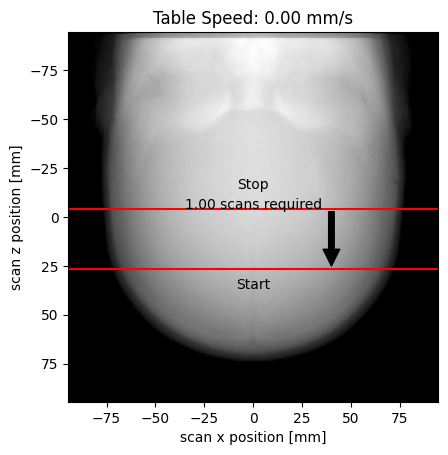

In [2]:
from insilicoICH.image_acquisition import Scanner, PhotonCountingScanner

scanner = PhotonCountingScanner(phantom, scanner_model='Siemens_NaetomAlpha') # Scanner_PCCT
scanner

lesion_level_mm = (phantom.get_CT_number_phantom().shape[0]/2 -
                   phantom._lesion_coords[0][0])*phantom.dz

scans = 1  # edit me

center = lesion_level_mm
width = scanner.nominal_aperature*scans
startZ = center - width / 4
endZ = center + width / 4

scanner.scout_view(startZ, endZ)

In [ ]:
acquisition_technique = dict(
    mA=500,
    kVp=120,
    views=1000,
    startZ=startZ,
    endZ=endZ,
    pitch=0
)

scanner.run_scan(**acquisition_technique)

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/1000 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


 53%|█████▎    | 529/1000 [37:28<35:49,  4.56s/it]  

In [ ]:


thresh = 70 # kV
scanner.run_recon(sliceThickness=1, threshold=thresh, enoise_threshold=False, kernel='soft')

recon_combined = scanner.recon.mean(axis=(0, 1))

In [ ]:
import matplotlib.pyplot as plt

ww, wl = 200, -10
disp = dict(cmap='gray', vmin=wl-ww/2, vmax=wl+ww/2)
f, axs = plt.subplots(1,3, gridspec_kw=dict(wspace=0, hspace=0), dpi=300)
axs[0].imshow(scanner.recon.mean(axis=1)[0], **disp)
axs[0].set_title(f'< {thresh} kV threshold')
axs[0].set_axis_off()
axs[1].imshow(scanner.recon.mean(axis=1)[1], **disp)
axs[1].set_title(f'>= {thresh} kV threshold')
axs[1].set_axis_off()
axs[2].imshow(recon_combined, **disp)
axs[2].set_title(f'averaged')
axs[2].set_axis_off()

In [ ]:
thresh = 70 # kV
scanner.run_recon(sliceThickness=1, threshold=thresh, enoise_threshold=True, kernel='soft')

recon_combined = scanner.recon.mean(axis=(0, 1))

ww, wl = 200, -10
disp = dict(cmap='gray', vmin=wl-ww/2, vmax=wl+ww/2)
f, axs = plt.subplots(1,3, gridspec_kw=dict(wspace=0, hspace=0), dpi=300)
axs[0].imshow(scanner.recon.mean(axis=1)[0], **disp)
axs[0].set_title(f'< {thresh} kV threshold')
axs[0].set_axis_off()
axs[1].imshow(scanner.recon.mean(axis=1)[1], **disp)
axs[1].set_title(f'>= {thresh} kV threshold')
axs[1].set_axis_off()
axs[2].imshow(recon_combined, **disp)
axs[2].set_title(f'averaged')
axs[2].set_axis_off()